In [58]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from itertools import combinations
import networkx as nx

from gudhi import AlphaComplex as AC

In [59]:
from src.abstract_subdivision import AbstractSubdivision

Subs = {i: AbstractSubdivision(i) for i in range(2,5)}

from src.relative_subdivision import subdivision
from src.alpha_builder import AlphaComplex, getAlphaComplex
from src.visualization import draw_2d_simplicial_complex, draw_Sup

In [60]:
!pip install triangle

Defaulting to user installation because normal site-packages is not writeable


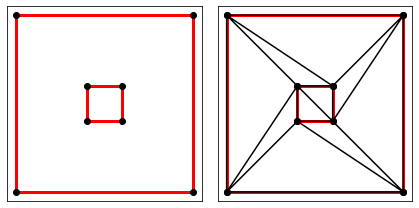

In [104]:
import triangle as tr
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Vertices (x, y)
pts = np.array([[0, 0], [10, 0], [10, 10], [0, 10],  # Outer square
                [4, 4], [6, 4], [6, 6], [4, 6]])      # Inner square

# 2. Define Segments (indices of pts that must stay connected)
# These are your fixed edges
seg = np.array([[0, 1], [1, 2], [2, 3], [3, 0],      # Outer boundary
                [4, 5], [5, 6], [6, 7], [7, 4]])      # Inner hole

# 3. Define Holes
# A "hole" is just a single coordinate inside the region you want to empty
holes = np.array([[5, 5]])

# 4. Perform Triangulation
# 'p' = planar straight line graph (uses segments)
# 'D' = Conforming Delaunay (ensures all triangles are Delaunay)
A = dict(vertices=pts, segments=seg, holes=holes)
A = dict(vertices=pts, segments=seg)
t = tr.triangulate(A, 'p')

# 5. Access Results
vertices = t['vertices']
triangles = t['triangles']

# Optional: Visualization
tr.compare(plt, A, t)
plt.show()


In [ ]:
tr.triangulate(

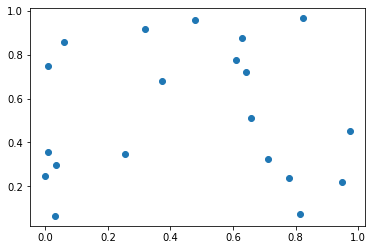

In [63]:
np.random.seed(13)
#np.random.seed(None)
pointsL = np.random.random_sample(size=(20,2))
plt.scatter(pointsL[:,0], pointsL[:,1])

In [64]:
L = getAlphaComplex(pointsL, .151)

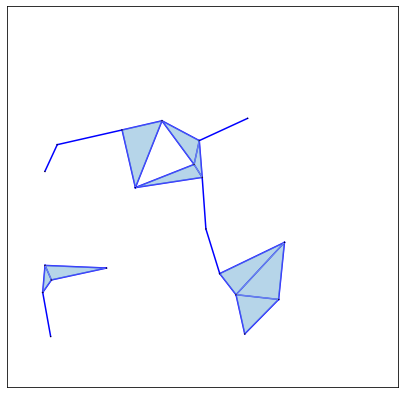

In [65]:
draw_2d_simplicial_complex(L, 7*pointsL)

In [89]:
fix_edges = sorted([sorted(x) for x in L if len(x)==2])
fix_edges = [ [x[0]+4 , x[1] + 4] for x in fix_edges ]

In [90]:
fix_edges;

In [95]:
pts = np.vstack([np.array([[0, 0], [1.5, 0], [1.5, 1.5], [0, 1.5]]) , pointsL])
seg = np.array( [[0, 1], [1, 2], [2, 3], [3, 0]] +  fix_edges)

In [96]:
pts.shape

(24, 2)

In [97]:
seg.shape

(32, 2)

<Figure size 576x576 with 0 Axes>

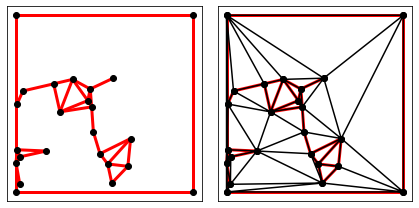

In [102]:
fig = plt.figure(figsize=(8,8))
A = dict(vertices=pts, segments=seg)
t = tr.triangulate(A, 'p')

# 5. Access Results
vertices = t['vertices']
triangles = t['triangles']

# Optional: Visualization
tr.compare(plt, A, t)
plt.show()

In [103]:
triangles

array([[22,  9, 13],
       [16, 22,  0],
       [22, 13, 18],
       [ 0, 22,  3],
       [16, 12,  9],
       [19, 12, 16],
       [ 9, 12, 13],
       [16,  9, 22],
       [16,  0, 19],
       [13, 12, 18],
       [ 3, 18, 10],
       [18,  3, 22],
       [10, 18, 11],
       [ 3, 10, 15],
       [15, 11, 21],
       [11, 15, 10],
       [ 7, 21, 11],
       [15, 21,  3],
       [18, 12, 11],
       [ 3, 21,  5],
       [11, 12, 20],
       [23, 19,  4],
       [19, 23, 12],
       [ 4, 19, 14],
       [23,  4,  6],
       [14,  1,  6],
       [ 1, 14, 19],
       [ 6,  1,  2],
       [14,  6,  4],
       [19,  0,  1],
       [23,  6, 20],
       [ 7,  8, 17],
       [ 7, 11,  8],
       [17,  8,  5],
       [ 7, 17, 21],
       [ 5,  8,  6],
       [ 5,  6,  2],
       [ 2,  3,  5],
       [ 6,  8, 20],
       [11, 20,  8],
       [ 5, 21, 17],
       [23, 20, 12]], dtype=int32)